# Phase 2 — Text Cleaning

Normalize Kickstarter campaign titles (`name`): lowercase, keep alphabetic tokens only, drop English stopwords, and store a cleaned text column for TF-IDF.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
IN_PATH = ROOT / "data" / "interim" / "ks_binary_base.csv"
OUT_PATH = ROOT / "data" / "interim" / "ks_text_cleaned.csv"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

STOPWORDS = set(ENGLISH_STOP_WORDS)
TOKEN_RE = re.compile(r"[^a-z]+")

## 1. Load interim base table

In [2]:
df = pd.read_csv(IN_PATH)
print(f"rows: {len(df):,}")
df[["name", "target"]].head()

rows: 331,672


,name,target
0,The Songs of Adelaide & Abullah,0
1,Greeting From Earth: ZGAC Arts Capsule For ET,0
2,Where is Hank?,0
3,ToshiCapital Rekordz Needs Help to Complete Album,0
4,Monarch Espresso Bar,1


## 2. Cleaning function

Pipeline per title:

1. Lowercase
2. Replace non-letters with spaces
3. Tokenize on whitespace
4. Drop stopwords and empty tokens
5. Rejoin surviving tokens

In [3]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = TOKEN_RE.sub(" ", text)
    tokens = [tok for tok in text.split() if tok and tok not in STOPWORDS]
    return " ".join(tokens)


samples = [
    "The Songs of Adelaide & Abullah",
    "Greeting From Earth: ZGAC Arts Capsule For ET",
    "Where is Hank?",
]
pd.DataFrame({"raw": samples, "cleaned": [clean_text(s) for s in samples]})

,raw,cleaned
0,The Songs of Adelaide & Abullah,songs adelaide abullah
1,Greeting From Earth: ZGAC Arts Capsule For ET,greeting earth zgac arts capsule et
2,Where is Hank?,hank


## 3. Apply cleaning to the full column

In [4]:
df["name_clean"] = df["name"].map(clean_text)
df["name_clean_tokens"] = df["name_clean"].str.split().str.len().fillna(0).astype(int)

empty_clean = int((df["name_clean"].str.strip() == "").sum())
print(f"empty cleaned titles: {empty_clean:,} ({100 * empty_clean / len(df):.2f}%)")

df[["name", "name_clean", "name_words", "name_clean_tokens"]].head(10)

empty cleaned titles: 761 (0.23%)


,name,name_clean,name_words,name_clean_tokens
0,The Songs of Adelaide & Abullah,songs adelaide abullah,6,3
1,Greeting From Earth: ZGAC Arts Capsule For ET,greeting earth zgac arts capsule et,8,6
2,Where is Hank?,hank,3,1
3,ToshiCapital Rekordz Needs Help to Complete Album,toshicapital rekordz needs help complete album,7,6
4,Monarch Espresso Bar,monarch espresso bar,3,3
5,Support Solar Roasted Coffee & Green Energy! ...,support solar roasted coffee green energy sola...,8,7
6,Chaser Strips. Our Strips make Shots their B*tch!,chaser strips strips make shots b tch,8,7
7,Of Jesus and Madmen,jesus madmen,4,2
8,Lisa Lim New CD!,lisa lim new cd,4,4
9,The Cottage Market,cottage market,3,2


### What this step shows

Titles lose filler words (`the`, `of`, `from`, `for`, …) and punctuation. A small share may become empty after stopword removal; those rows are dropped before TF-IDF so the text matrix stays meaningful.

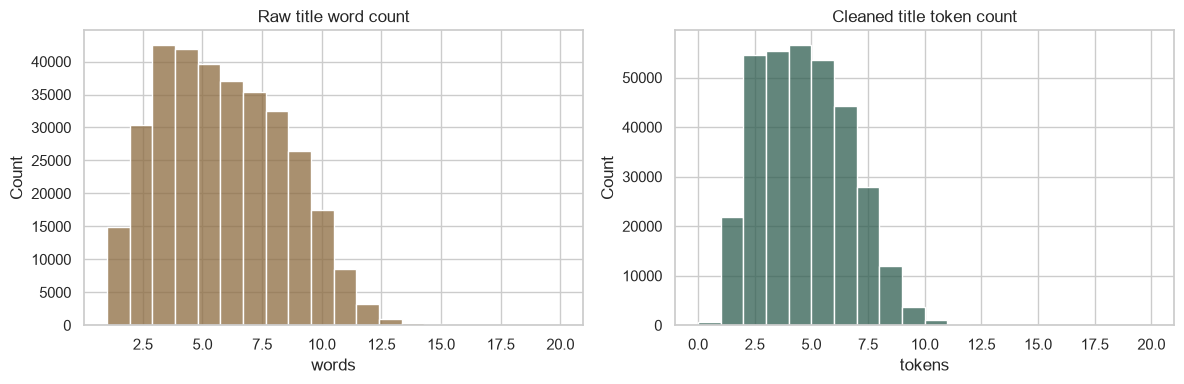

,raw_words,clean_tokens
count,331672.00,331672.00
mean,5.63,4.20
std,2.76,1.97
min,1.00,0.00
25%,3.00,3.00
50%,5.00,4.00
75%,8.00,6.00
max,29.00,22.00


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["name_words"].clip(0, 20), bins=20, ax=axes[0], color="#8c6b3f")
axes[0].set_title("Raw title word count")
axes[0].set_xlabel("words")

sns.histplot(df["name_clean_tokens"].clip(0, 20), bins=20, ax=axes[1], color="#2f5d50")
axes[1].set_title("Cleaned title token count")
axes[1].set_xlabel("tokens")

plt.tight_layout()
fig.savefig(FIG_DIR / "02_title_token_counts.png", dpi=150)
plt.show()

pd.DataFrame(
    {
        "raw_words": df["name_words"].describe(),
        "clean_tokens": df["name_clean_tokens"].describe(),
    }
).round(2)

### What this figure shows

Cleaning shortens titles: token counts shift down after stopwords and non-letters are removed. Most campaigns still keep a few content tokens — enough for a capped TF-IDF matrix in Phase 3.

## 4. Quick vocabulary peek

In [6]:
from collections import Counter

token_counts = Counter()
for text in df["name_clean"]:
    if text:
        token_counts.update(text.split())

top_tokens = pd.DataFrame(token_counts.most_common(20), columns=["token", "count"])
top_tokens

,token,count
0,s,28562
1,album,12840
2,new,12506
3,film,10613
4,project,10445
5,book,9040
6,art,7548
7,game,7515
8,music,6672
9,help,5771


### What this table shows

Frequent surviving tokens tend to be thematic words from campaign naming (project nouns, genre cues, media types). That is the signal TF-IDF will weigh next.

## 5. Save cleaned interim table

In [7]:
clean = df[df["name_clean"].str.strip() != ""].copy()
dropped = len(df) - len(clean)
print(f"kept: {len(clean):,} | dropped empty cleaned titles: {dropped:,}")

clean.to_csv(OUT_PATH, index=False)
print(f"saved: {OUT_PATH}")
clean[["name", "name_clean", "target"]].head()

kept: 330,911 | dropped empty cleaned titles: 761


saved: /Users/koriginjasathvik/Desktop/ML_Summer_Project/data/interim/ks_text_cleaned.csv


,name,name_clean,target
0,The Songs of Adelaide & Abullah,songs adelaide abullah,0
1,Greeting From Earth: ZGAC Arts Capsule For ET,greeting earth zgac arts capsule et,0
2,Where is Hank?,hank,0
3,ToshiCapital Rekordz Needs Help to Complete Album,toshicapital rekordz needs help complete album,0
4,Monarch Espresso Bar,monarch espresso bar,1


## Phase 2 takeaways

- Cleaning rules: lowercase → alphabetic tokens only → English stopword removal.
- New column: `name_clean` (plus `name_clean_tokens` for QA).
- Empty cleaned titles are removed from the interim export.
- Output: `data/interim/ks_text_cleaned.csv`.
- Notes: [`docs/text-cleaning.md`](../docs/text-cleaning.md).